# demiwtg 数据质量分析

数据源：三机分片清单（A: docs/image-shard-0, B: docs/image-shard-1, 本机: docs/image-shard-2）+ 共享盘页文件。

运行方式：在本机（10.3.0.14）venv 里跑；第 1 格会经 ssh 拉取 A/B 最新清单（失败则退回上次镜像）。

产出：docs 域名/权威分布、段落绑定质量、壳页抽样、图像源分布与重复检测、概念覆盖交叉、商业域复核清单。

In [1]:
import json, os, subprocess, shutil
from pathlib import Path
from urllib.parse import urlparse
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

WORK = Path('/tmp/kilo/quality'); WORK.mkdir(parents=True, exist_ok=True)
PAGES_ROOT = Path('/lhcos-data/demiwtg-data/datasets/demiwtg/pages')
LOCAL_META = Path('/home/ubuntu/lake/meta')

SOURCES = {
    'A(0/3)':  ('pipeline-a', 'docs-shard-0-of-3.jsonl', 'image-shard-0-of-3.jsonl'),
    'B(1/3)':  ('pipeline-b', 'docs-shard-1-of-3.jsonl', 'image-shard-1-of-3.jsonl'),
    '本机(2/3)': (None, 'docs-shard-2-of-3.jsonl', 'image-shard-2-of-3.jsonl'),
}
for tag, (host, docs_f, img_f) in SOURCES.items():
    for f in (docs_f, img_f):
        dst = WORK / f
        try:
            if host:
                subprocess.run(['scp', '-q', '-o', 'ConnectTimeout=8',
                                f'{host}:/home/ubuntu/lake/meta/{f}', str(dst)], check=True)
            else:
                shutil.copy(LOCAL_META / f, dst)
        except Exception as e:
            print(f'[{tag}] {f} 同步失败（用已有镜像）: {e}')
print('同步完成:', {p.name: p.stat().st_size for p in sorted(WORK.glob('*.jsonl'))})

同步完成: {'docs-shard-0-of-3.jsonl': 808877, 'docs-shard-1-of-3.jsonl': 831637, 'docs-shard-2-of-3.jsonl': 932887, 'image-shard-0-of-3.jsonl': 5781735, 'image-shard-1-of-3.jsonl': 4003190, 'image-shard-2-of-3.jsonl': 4009954}


In [2]:
def load(pattern):
    rows = []
    for p in sorted(WORK.glob(pattern)):
        tag = next(t for t, (_, d, i) in SOURCES.items() if d == p.name or i == p.name)
        for line in open(p):
            try:
                r = json.loads(line); r['_shard'] = tag; rows.append(r)
            except Exception: pass
    return pd.DataFrame(rows)

docs = load('docs-shard-*.jsonl')
imgs = load('image-shard-*.jsonl')
docs['domain'] = docs['url'].map(lambda u: urlparse(u).netloc)
print(f'docs {len(docs)} 行（页级去重后 {docs.page_sha.nunique()}）｜ images {len(imgs)} 行')
docs.head(3)

docs 6249 行（页级去重后 2574）｜ images 17782 行


,page_sha,url,concepts,authority,title,path,n_passages,n_images,query,fetched_at,_shard,domain
0,1cc977f1b677d4da3f7c97c43e357abc50bb1f25c24e02...,https://en.wikipedia.org/wiki/NAO,[软银 NAO],wiki,NAO,pages/1c/1cc977f1b677d4da3f7c97c43e357abc50bb1...,25,0,NAO,1.788693e+09,A(0/3),en.wikipedia.org
1,b5893ce94a5808402e1dcddba1a5b126dd0f4cdb0b6f6a...,https://www.roboatlas.ai/zh-CN/products/nao,[软银 NAO],serp,软银机器人 Nao 人形机器人参数、价格与开发支持 ...,pages/b5/b5893ce94a5808402e1dcddba1a5b126dd0f4...,2,7,软银 NAO,1.788693e+09,A(0/3),www.roboatlas.ai
2,40ca63f32e52cc4e4a82a3cf986e00808ec6764d71c0fd...,https://baike.baidu.com/item/NAO/18025769,[软银 NAO],serp,NAO（仿人智能机器人）_百度百科,pages/40/40ca63f32e52cc4e4a82a3cf986e00808ec67...,9,2,软银 NAO,1.788693e+09,A(0/3),baike.baidu.com


## 1. docs 域名分布与权威结构

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


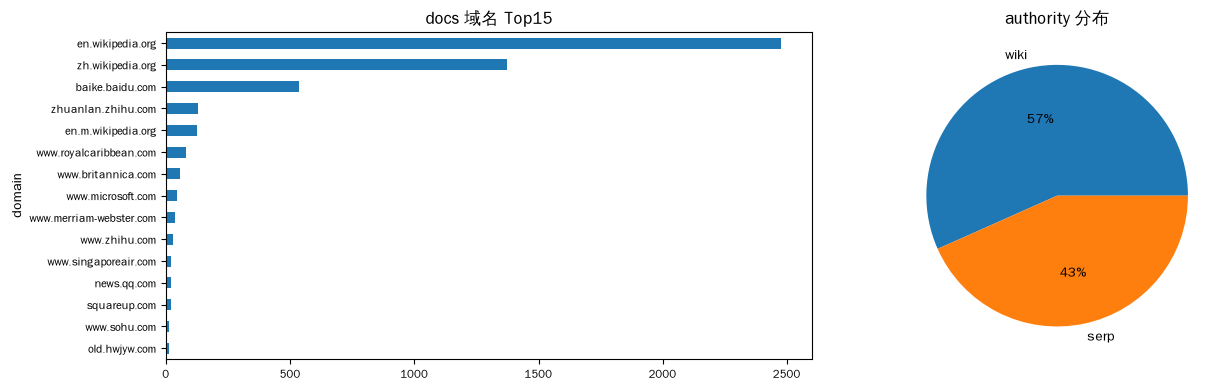

wiki 占比 64% ｜ 图文绑定页 27% ｜ 零段页 0


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
top = docs.domain.value_counts().head(15)[::-1]
top.plot.barh(ax=ax[0], title='docs 域名 Top15', fontsize=8)
docs.authority.value_counts().plot.pie(ax=ax[1], autopct='%.0f%%', title='authority 分布')
plt.tight_layout(); plt.show()
wiki = docs.domain.str.contains('wikipedia').mean()
print(f'wiki 占比 {wiki:.0%} ｜ 图文绑定页 {(docs.n_images > 0).mean():.0%} ｜ 零段页 {(docs.n_passages == 0).sum()}')

## 2. 段落绑定质量（n_passages 分布 + 壳页抽样）

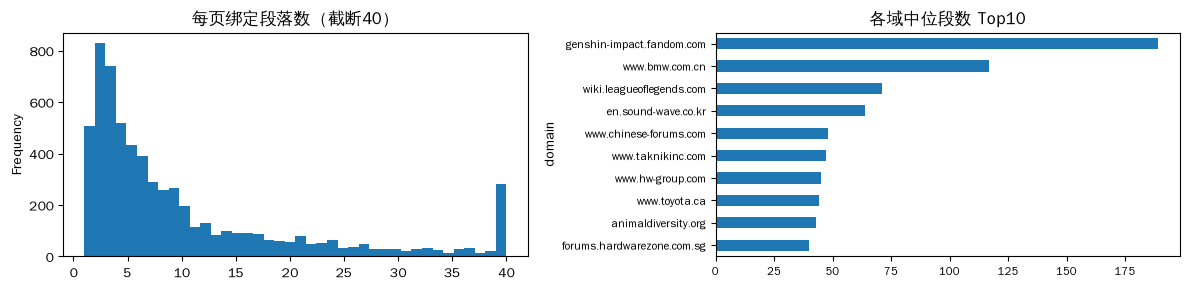

抽样 40 页：壳页率（<2000B）10%，读取失败 0 页


,domain,title,page_bytes
965,en.wikipedia.org,Sunward Aerospace Group,900
639,zh.wikipedia.org,黄县染窗花,911
4669,zh.wikipedia.org,巴金旧居,731
2463,en.wikipedia.org,Honorary Palme d'Or - Wikipedia,1560


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
docs.n_passages.clip(upper=40).plot.hist(bins=40, ax=ax[0], title='每页绑定段落数（截断40）')
docs.groupby('domain').n_passages.median().sort_values(ascending=False).head(10)[::-1].plot.barh(ax=ax[1], title='各域中位段数 Top10', fontsize=8)
plt.tight_layout(); plt.show()

SHELL_BYTES = 2000   # 小于此字节的页文件疑似壳页
DS_ROOT = PAGES_ROOT.parent   # path 字段形如 pages/xx/sha.md（相对 datasets/demiwtg）
sample = docs.sample(min(40, len(docs)), random_state=7)
sizes = []
for _, r in sample.iterrows():
    f = DS_ROOT / r.path if r.path else PAGES_ROOT / (r.page_sha[:2] + '/' + r.page_sha + '.md')
    sizes.append(f.stat().st_size if f.exists() else -1)
sample = sample.assign(page_bytes=sizes)
shell = (sample.page_bytes < SHELL_BYTES).mean()
print(f'抽样 {len(sample)} 页：壳页率（<{SHELL_BYTES}B）{shell:.0%}，读取失败 {(sample.page_bytes < 0).sum()} 页')
sample.loc[sample.page_bytes < SHELL_BYTES, ['domain', 'title', 'page_bytes']]

## 3. 随机深读 N 页（人工 review 用）

In [5]:
def show_page(row, chars=400):
    f = DS_ROOT / row.path if row.path else PAGES_ROOT / (row.page_sha[:2] + '/' + row.page_sha + '.md')
    print(f"### {row.title}\n{row.url}\n概念: {row.concepts}｜段{row.n_passages} 图{row.n_images}｜{row._shard}\n---")
    print(f.read_text()[:chars] if f.exists() else '(页文件缺失)')
    print()

for _, r in docs.sample(3, random_state=42).iterrows():
    show_page(r)

### Streptomyces
https://en.wikipedia.org/wiki/Streptomyces
概念: ['链霉菌']｜段6 图0｜B(1/3)
---
[Jump to content](https://en.wikipedia.org/wiki/Streptomyces#bodyContent)
Main menu
Main menu
move to sidebar hide
Navigation 
  * [Main page](https://en.wikipedia.org/wiki/Main_Page "Visit the main page \[alt-z\]")
  * [Contents](https://en.wikipedia.org/wiki/Wikipedia:Contents "Guides to browsing Wikipedia")
  * [Current events](https://en.wikipedia.org/wiki/Portal:Current_events "Articles relat

### Festival of San Fermín
https://en.wikipedia.org/wiki/Festival_of_San_Fermín
概念: ['奔牛节']｜段15 图0｜A(0/3)
---
The festival of San Fermín is a week-long, traditional celebration held annually in the city of Pamplona, Navarre, Spain. The celebrations start at noon on 6 July and continue until midnight on 14 July. A firework (chupinazo) starts the celebrations and the popular song Pobre de mí  is sung at the end.
The most known event of the festival is the running of the bulls, which begins at 8 am each day

## 4. 图像：源分布 / 每概念图数 / 重复检测

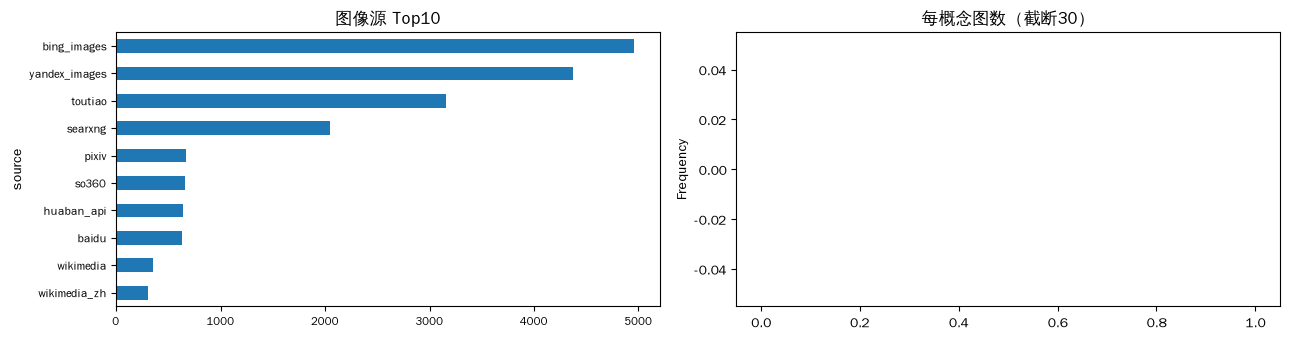

重复 sha256: 959 行（5.4%）


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
imgs['source'] = imgs.get('source', imgs.get('engine', pd.Series('?' * len(imgs))))
imgs.source.value_counts().head(10)[::-1].plot.barh(ax=ax[0], title='图像源 Top10', fontsize=8)
per_concept = imgs.groupby(imgs['queries'].map(lambda q: q[0] if isinstance(q, list) and q else None)).size()
per_concept.clip(upper=30).plot.hist(bins=30, ax=ax[1], title='每概念图数（截断30）')
plt.tight_layout(); plt.show()

for col in ('sha256', 'image_sha', 'blob_sha', 'sha', 'content_url'):
    if col in imgs.columns:
        dup = imgs[col].duplicated().sum()
        print(f'重复 {col}: {dup} 行（{dup/len(imgs):.1%}）'); break
else:
    print('可用列:', imgs.columns.tolist())

## 5. 概念覆盖交叉（有图 / 有 docs / 双缺）

In [7]:
docs_c = set(docs.concepts.explode()) if docs.concepts.apply(lambda x: isinstance(x, list)).all() else set(docs.concepts)
img_c = set(imgs.queries.explode().dropna()) if 'queries' in imgs else set()
both, only_i, only_d, neither = len(img_c & docs_c), len(img_c - docs_c), len(docs_c - img_c), '—'
print(f'有图概念 {len(img_c)}｜有docs概念 {len(docs_c)}｜交集 {both}｜仅图 {only_i}｜仅docs {only_d}')
print('仅 docs 无图的概念样例（wiki 0绑定图问题相关）:', list(docs_c - img_c)[:10])

有图概念 292｜有docs概念 263｜交集 263｜仅图 29｜仅docs 0
仅 docs 无图的概念样例（wiki 0绑定图问题相关）: []


## 6. 商业域复核清单（-40 惩罚效果验证）

In [8]:
COMMERCIAL = ('amazon.', 'ebay.', 'taobao.', 'jd.com', 'tmall.', 'bolt.eu', 'aliexpress', 'walmart.')
comm = docs[docs.domain.str.contains('|'.join(COMMERCIAL), na=False)]
print(f'商业域混入页: {len(comm)}')
comm[['domain', 'title', 'n_passages']].head(10)

商业域混入页: 20


,domain,title,n_passages
926,www.taobao.com,海竿 - Top 5万件海竿 - 2026年9月更新 - 淘宝Taobao｜天猫Tmall,1
1566,www.taobao.com,平衡木 - Top 1000件平衡木 - 2026年9月更新 - 淘宝Taobao ...,1
1818,item.m.jd.com,土壤采样瓶VOC棕色广口玻璃瓶样品瓶土壤瓶60 100 250 ... - 京东,4
1856,www.amazon.com,Amazon.com: Treadmill,4
1864,www.amazon.com,Amazon.com: One-way Mirror,3
1874,www.amazon.com,Amazon Best Sellers: Best Diabetic Test Strips,2
2898,www.taobao.com,海竿 - Top 5万件海竿 - 2026年9月更新 - 淘宝Taobao｜天猫Tmall,1
3357,item.m.jd.com,海竿钓鱼竿套装抛竿甩竿远投竿超硬海钓竿海杆全套鱼杆渔具2.1m m3 ...,5
3609,www.taobao.com,平衡木 - Top 1000件平衡木 - 2026年9月更新 - 淘宝Taobao ...,1
3853,cread.jd.com,动物博物馆-- （法）希尔维·贝居埃尔-京东阅读,8


## 7. 采集时间线（fetch 速率是否健康）

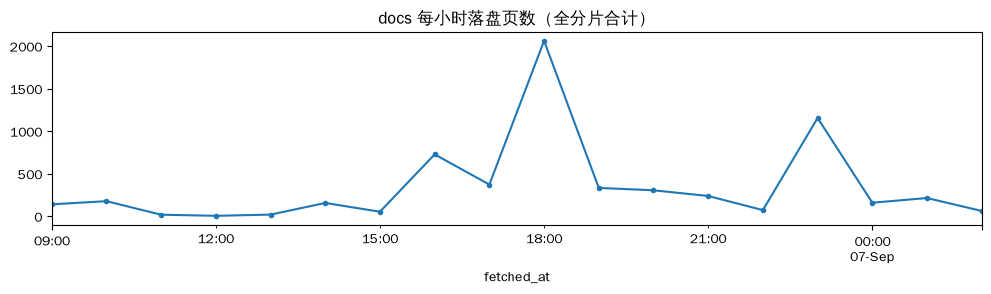

注意 23:25Z 后应有显著抬升（supervise 双清单修复释放 docs 产能）


In [9]:
ts = pd.to_datetime(docs.fetched_at, errors='coerce', unit='s', origin='unix') if docs.fetched_at.dtype != object else pd.to_datetime(docs.fetched_at, errors='coerce')
ts = ts.dropna()
if len(ts):
    per_h = ts.dt.floor('h').value_counts().sort_index()
    per_h.plot(figsize=(12, 2.5), title='docs 每小时落盘页数（全分片合计）', marker='.')
    plt.show()
    print('注意 23:25Z 后应有显著抬升（supervise 双清单修复释放 docs 产能）')